In [ ]:
# Installer timm
!pip install timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 30.4 MB/s eta 0:00:00


In [ ]:
#mid_level implem swin

import os
import torch
import numpy as np
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm import tqdm
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import timm
from torch.nn.init import xavier_uniform_
from PIL import Image
from sklearn.metrics import f1_score, precision_score, recall_score  # For evaluation metrics
from torch.utils.tensorboard import SummaryWriter  # For logging
from torch.cuda.amp import GradScaler, autocast




# Constants
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 1
PREPROCESSED_DIR = "/content/drive/MyDrive/preprocessed_eurosat"
DATASET_FRACTION=1.0
total_samples = 27000


# Load or preprocess the dataset
def load_or_preprocess_data(dataset_fraction=1.0, train_split=0.7, val_split=0.15, test_split=0.15):
    """Load or preprocess the EuroSAT dataset."""
    if train_split + val_split + test_split != 1.0:
        raise ValueError("Train, validation, and test splits must sum to 1.0")
    try:
        if os.path.exists(os.path.join(PREPROCESSED_DIR, "train_data.npz")):
            print("Loading preprocessed data...")
            with np.load(os.path.join(PREPROCESSED_DIR, "train_data.npz")) as data:
                train_images, train_labels = data['images'], data['labels']
            with np.load(os.path.join(PREPROCESSED_DIR, "val_data.npz")) as data:
                val_images, val_labels = data['images'], data['labels']
            with np.load(os.path.join(PREPROCESSED_DIR, "test_data.npz")) as data:
                test_images, test_labels = data['images'], data['labels']
        else:
            print("Processing dataset...")
            samples_to_load = int(total_samples * dataset_fraction)
            dataset = tfds.load("eurosat", split=f"train[:{samples_to_load}]", as_supervised=True)
            dataset = list(tfds.as_numpy(dataset))
            train_end = int(train_split * samples_to_load)
            val_end = int((train_split + val_split) * samples_to_load)
            train_data = dataset[:train_end]
            val_data = dataset[train_end:val_end]
            test_data = dataset[val_end:]
            def process_dataset(data):
                images, labels = [], []
                for img, label in data:
                    images.append(img)
                    labels.append(label)
                return np.stack(images), np.array(labels)
            train_images, train_labels = process_dataset(train_data)
            val_images, val_labels = process_dataset(val_data)
            test_images, test_labels = process_dataset(test_data)
            os.makedirs(PREPROCESSED_DIR, exist_ok=True)
            np.savez_compressed(os.path.join(PREPROCESSED_DIR, "train_data.npz"), images=train_images, labels=train_labels)
            np.savez_compressed(os.path.join(PREPROCESSED_DIR, "val_data.npz"), images=val_images, labels=val_labels)
            np.savez_compressed(os.path.join(PREPROCESSED_DIR, "test_data.npz"), images=test_images, labels=test_labels)
    except Exception as e:
        print(f"Error: {e}")
        raise e
    return train_images, train_labels, val_images, val_labels, test_images, test_labels

# Dataset Class
class EuroSATDataset(Dataset):
    def __init__(self, images, labels, transforms):
        self.images = images
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        image = Image.fromarray(image)
        image = self.transforms(image)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

# Training Data Transforms
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # Redimensionnement
    transforms.RandomHorizontalFlip(),  # Flip horizontal
    transforms.RandomVerticalFlip(),  # Flip vertical
    transforms.RandomRotation(15),  # Rotation
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Ajustement de la couleur
    transforms.RandomCrop(IMG_SIZE, padding=4),  # Découpe aléatoire
    transforms.ToTensor(),  # Conversion en tenseur (doit venir après les augmentations)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Normalisation
])

# Validation Data Transforms
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # Redimensionnement
    transforms.ToTensor(),  # Conversion en tenseur
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Normalisation
])


# Mid-Level Fusion Model

# CBAM Module amélioré
class CBAM(nn.Module):
    def __init__(self, channels, reduction_ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        # Attention canal
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction_ratio, kernel_size=1),
            nn.ReLU(),
            nn.BatchNorm2d(channels // reduction_ratio),
            nn.Conv2d(channels // reduction_ratio, channels, kernel_size=1),
            nn.Sigmoid()
        )
        # Attention spatiale
        self.spatial_attention = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, groups=1),
            nn.ReLU(),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Channel attention
        ca = self.channel_attention(x) * x
        # Spatial attention
        max_out, _ = ca.max(dim=1, keepdim=True)
        avg_out = ca.mean(dim=1, keepdim=True)
        sa = self.spatial_attention(torch.cat([max_out, avg_out], dim=1)) * ca
        return sa


# Mid-Level Fusion Model with CBAM
class MidLevelFusionWithCBAM(nn.Module):
    def __init__(self, num_classes):
        super(MidLevelFusionWithCBAM, self).__init__()

        # Swin Transformer
        self.swin = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=0)
        self.swin_fc = nn.Sequential(
            nn.Linear(768, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128)
        )

        # EfficientNet with CBAM
        self.efficientnet = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)
        self.cbam = CBAM(channels=1280)
        self.efficientnet_fc = nn.Sequential(
            nn.Linear(1280, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128)
        )

        # Projections before multihead attention
        self.swin_proj = nn.Linear(128, 128)
        self.efficientnet_proj = nn.Linear(128, 128)

        # Multihead Attention for fusion
        self.multihead_attention = nn.MultiheadAttention(embed_dim=128, num_heads=4, batch_first=True)

        # Projection and normalization after concatenation
        self.projection_layer = nn.Linear(256, 128)
        self.layer_norm = nn.LayerNorm(128)

        # Classification layers
        self.fusion_fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.fc_combined = nn.Linear(64, num_classes)

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        # Initialize weights for linear layers and projections
        for module in [self.swin_fc, self.efficientnet_fc, self.fusion_fc, self.swin_proj, self.efficientnet_proj, self.projection_layer]:
            if isinstance(module, nn.Sequential):
                for layer in module:
                    if isinstance(layer, nn.Linear):
                        nn.init.xavier_uniform_(layer.weight)
                        if layer.bias is not None:
                            nn.init.constant_(layer.bias, 0)
            elif isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
        # Initialize BatchNorm layers
        for m in self.modules():
            if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, image):
      # Swin Transformer features
      swin_features = self.swin.forward_features(image)  # [batch_size, 7, 7, 768]
      #print(f"Swin features (before transpose): {swin_features.shape}")

      # Transposer les dimensions de NHWC à NCHW
      swin_features = swin_features.permute(0, 3, 1, 2)  # [batch_size, 768, 7, 7]
      #print(f"Swin features (after transpose): {swin_features.shape}")

      # Continue with adaptive pooling
      swin_features = nn.functional.adaptive_avg_pool2d(swin_features, (1, 1))  # [batch_size, 768, 1, 1]
      #print(f"Swin features (after pooling): {swin_features.shape}")

      swin_features = torch.flatten(swin_features, 1)  # [batch_size, 768]
      #print(f"Swin features (flattened): {swin_features.shape}")

      swin_features = self.swin_fc(swin_features)  # [batch_size, 128]
      #print(f"Swin features (after swin_fc): {swin_features.shape}")

      # EfficientNet features with CBAM
      efficientnet_features = self.efficientnet.forward_features(image)
      #print(f"EfficientNet features (before CBAM): {efficientnet_features.shape}")  # Inspect dimensions
      efficientnet_features = self.cbam(efficientnet_features)
      #print(f"EfficientNet features (after CBAM): {efficientnet_features.shape}")  # Should match input shape
      efficientnet_features = nn.functional.adaptive_avg_pool2d(efficientnet_features, (1, 1))
      #print(f"EfficientNet features (after pooling): {efficientnet_features.shape}")  # Should be [batch_size, 1280, 1, 1]
      efficientnet_features = torch.flatten(efficientnet_features, 1)
      #print(f"EfficientNet features (flattened): {efficientnet_features.shape}")  # Should be [batch_size, 1280]
      efficientnet_features = self.efficientnet_fc(efficientnet_features)
      #print(f"EfficientNet features (after efficientnet_fc): {efficientnet_features.shape}")  # Should be [batch_size, 128]

      # Projections
      swin_features = self.swin_proj(swin_features)
      #print(f"Swin features (after swin_proj): {swin_features.shape}")  # Should be [batch_size, 128]
      efficientnet_features = self.efficientnet_proj(efficientnet_features)
      #print(f"EfficientNet features (after efficientnet_proj): {efficientnet_features.shape}")  # Should be [batch_size, 128]

      # Concatenation, projection, and normalization
      combined_features = torch.cat([swin_features, efficientnet_features], dim=1)
      #print(f"Combined features (after concatenation): {combined_features.shape}")  # Should be [batch_size, 256]
      combined_features = self.projection_layer(combined_features)
      #print(f"Combined features (after projection_layer): {combined_features.shape}")  # Should be [batch_size, 128]
      combined_features = self.layer_norm(combined_features)
      #print(f"Combined features (after layer_norm): {combined_features.shape}")  # Should be [batch_size, 128]

      # Attention multi-têtes
      combined_features = combined_features.unsqueeze(1)
      #print(f"Combined features (after unsqueeze): {combined_features.shape}")  # Should be [batch_size, 1, 128]
      combined_features, _ = self.multihead_attention(combined_features, combined_features, combined_features)
      #print(f"Combined features (after multihead_attention): {combined_features.shape}")  # Should be [batch_size, 1, 128]
      combined_features = combined_features.squeeze(1)
      #print(f"Combined features (after squeeze): {combined_features.shape}")  # Should be [batch_size, 128]

      # Classification
      combined_features = self.fusion_fc(combined_features)
      #print(f"Combined features (after fusion_fc): {combined_features.shape}")  # Should be [batch_size, 64]
      output = self.fc_combined(combined_features)
      #print(f"Output shape: {output.shape}")  # Should be [batch_size, num_classes]

      return output

In [ ]:
# Training, Validation, and Test Functions
def train_one_epoch(model, dataloader, optimizer, criterion, scaler=None): # Add scaler for AMP
    model.train()
    train_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(dataloader, desc="Training"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        if scaler: # Use AMP if scaler is provided
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else: # Regular training without AMP
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()


        train_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return train_loss / len(dataloader), 100. * correct / total


def validate(model, dataloader, criterion):
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)  # Appeler directement le modèle
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return val_loss / len(dataloader), 100. * correct / total



def evaluate_metrics(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average="weighted")
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    return f1, precision, recall


def train_model_with_fine_tuning(model, train_dataloader, val_dataloader, test_dataloader, optimizer, criterion,
                                initial_epochs, fine_tune_phases, fine_tune_epochs, patience, lr_factor,
                                writer=None, scaler=None):
    best_val_loss = float('inf')
    patience_counter = 0

    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], [] #Initialize lists inside the function


    # Initial training phase (only train the fusion layers)
    print("Initial training phase...")
    for epoch in range(initial_epochs):
        train_loss, train_acc = train_one_epoch(model, train_dataloader, optimizer, criterion, scaler)
        val_loss, val_acc = validate(model, val_dataloader, criterion)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

        if writer:
            writer.add_scalar("Loss/Train", train_loss, epoch)
            writer.add_scalar("Accuracy/Train", train_acc, epoch)
            writer.add_scalar("Loss/Val", val_loss, epoch)
            writer.add_scalar("Accuracy/Val", val_acc, epoch)


        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_model_swin.pth")
        else:
            patience_counter += 1
            print(f"Early stopping patience counter: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    # Fine-tuning phases
    for phase in range(fine_tune_phases):
        print(f"Fine-tuning phase {phase + 1}...")

        if phase == 0:  # Unfreeze Swin and EfficientNet FC layers
            for param in model.swin_fc.parameters():
                param.requires_grad = True
            for param in model.efficientnet_fc.parameters():
                param.requires_grad = True
        elif phase == 1:  # Unfreeze EfficientNet completely
            for param in model.efficientnet.parameters():
                param.requires_grad = True
        elif phase == 2:  # Unfreeze some Swin blocks (adjust layer names as needed)
            unfreeze_layers = ['layers.3', 'norm']  # Example layers, adapt to your Swin version
            for name, param in model.swin.named_parameters():
                if any(layer in name for layer in unfreeze_layers):
                    param.requires_grad = True
        elif phase >= 3:  # Unfreeze Swin Transformer completely
            for param in model.swin.parameters():
                param.requires_grad = True


        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Total parameters: {total_params}, Trainable parameters: {trainable_params}")


        # Learning rate scheduler
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5, verbose=True)

        patience_counter = 0
        best_val_loss_phase = float('inf')

        for epoch in range(fine_tune_epochs):
            train_loss, train_acc = train_one_epoch(model, train_dataloader, optimizer, criterion, scaler)
            val_loss, val_acc = validate(model, val_dataloader, criterion)
            f1, precision, recall = evaluate_metrics(model, val_dataloader)

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
                  f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}, F1={f1:.4f}, Precision={precision:.4f}, Recall={recall:.4f}")

            train_losses.append(train_loss) #Append metrics for plotting
            val_losses.append(val_loss)
            train_accuracies.append(train_acc)
            val_accuracies.append(val_acc)

            if writer:
                global_step = initial_epochs + (phase * fine_tune_epochs) + epoch
                writer.add_scalar("Loss/Train", train_loss, global_step)
                writer.add_scalar("Accuracy/Train", train_acc, global_step)
                writer.add_scalar("Loss/Val", val_loss, global_step)
                writer.add_scalar("Accuracy/Val", val_acc, global_step)
                writer.add_scalar("F1/Val", f1, global_step)
                writer.add_scalar("Precision/Val", precision, global_step)
                writer.add_scalar("Recall/Val", recall, global_step)


            if val_loss < best_val_loss_phase:
                best_val_loss_phase = val_loss
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    torch.save(model.state_dict(), "best_model_swin.pth")
                patience_counter = 0
            else:
                patience_counter += 1
                print(f"Early stopping patience counter: {patience_counter}/{patience}")
                if patience_counter >= patience:
                    print("Early stopping triggered.")
                    break
            scheduler.step(val_loss)  # Step the scheduler after each epoch

    # Load best model and evaluate on the test set
    model.load_state_dict(torch.load("best_model_swin.pth"))
    test_loss, test_acc = validate(model, test_dataloader, criterion)
    test_f1, test_precision, test_recall = evaluate_metrics(model, test_dataloader)  # Calculate metrics
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}, "
          f"Test F1: {test_f1:.4f}, Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}")
    return model, train_losses, val_losses, train_accuracies, val_accuracies

def plot_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curves')

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Training Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy Curves')

    plt.tight_layout()
    plt.show()


In [ ]:
if __name__ == "__main__":
    # Load preprocessed data
    train_images, train_labels, val_images, val_labels, test_images, test_labels = load_or_preprocess_data(DATASET_FRACTION)

    # Create datasets and dataloaders
    train_dataset = EuroSATDataset(train_images, train_labels, train_transforms)
    val_dataset = EuroSATDataset(val_images, val_labels, val_transforms)
    test_dataset = EuroSATDataset(test_images, test_labels, val_transforms)

    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
    test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

    # Lists to store metrics for plotting (moved outside the training loop)
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

    # Create model
    model = MidLevelFusionWithCBAM(NUM_CLASSES).to(DEVICE)

    # Initial freezing of layers (important for fine-tuning)
    for param in model.swin.parameters():
        param.requires_grad = False
    for param in model.efficientnet.parameters():
        param.requires_grad = False

    # Define optimizer and criterion
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    # TensorBoard writer (optional)
    writer = SummaryWriter()  # Comment out if you don't want TensorBoard logging

    # GradScaler for AMP (optional, but recommended)
    scaler = GradScaler()

    # Fine-tuning and training
    trained_model, train_losses, train_accs, val_losses, val_accs = train_model_with_fine_tuning(
        model=model,
        train_dataloader=train_dataloader,
        val_dataloader=val_dataloader,
        test_dataloader=test_dataloader,
        optimizer=optimizer,
        criterion=criterion,
        initial_epochs=10,        # Example, adjust as needed
        fine_tune_phases=5,      # Example, adjust as needed
        fine_tune_epochs=10,      # Example, adjust as needed
        patience=10,              # Example, adjust as needed
        lr_factor=0.5,           # Example, adjust as needed
        writer=writer,          # Pass the writer for TensorBoard logging
        scaler=scaler           # Pass the GradScaler for AMP
    )

    # Test the model
    # Test the model
    test_loss, test_acc = validate(trained_model, test_dataloader, criterion)
    test_f1, test_precision, test_recall = evaluate_metrics(trained_model, test_dataloader)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}, "
          f"Test F1: {test_f1:.4f}, Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}")


Loading preprocessed data...


<ipython-input-7-c4264814365b>:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Initial training phase...


Training:   0%|          | 0/296 [00:00<?, ?it/s]<ipython-input-4-bd577ab7324b>:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation: 100%|██████████| 64/64 [00:09<00:00,  6.71it/s]


Epoch 1: Train Loss=1.3078, Train Acc=67.5556, Val Loss=0.8574, Val Acc=85.6543


...

Epoch 5: Train Loss=0.1582, Train Acc=95.1640, Val Loss=0.1499, Val Acc=94.9136, F1=0.9490, Precision=0.9493, Recall=0.9491


<ipython-input-4-bd577ab7324b>:173: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model_swin.pth"))
Validation: 100%|██████████| 64/64

Test Loss: 0.1361, Test Accuracy: 95.6296, Test F1: 0.9561, Test Precision: 0.9564, Test Recall: 0.9563


Validation: 100%|██████████| 64/64 [00:09<00:00,  6.79it/s]


Test Loss: 0.1361, Test Accuracy: 95.6296, Test F1: 0.9561, Test Precision: 0.9564, Test Recall: 0.9563


Train predictions: 18900
Validation predictions: 4050
Test predictions: 4050
***** Train Classification Report *****
              precision    recall  f1-score   support

     class_0       0.97      0.98      0.97      2122
     class_1       0.98      0.99      0.98      2143
     class_2       0.95      0.98      0.96      2067
     class_3       0.96      0.95      0.95      1756
     class_4       0.99      0.99      0.99      1756
     class_5       0.95      0.95      0.95      1382
     class_6       0.97      0.92      0.95      1718
     class_7       0.99      0.99      0.99      2095
     class_8       0.95      0.95      0.95      1754
     class_9       0.99      0.99      0.99      2107

    accuracy                           0.97     18900
   macro avg       0.97      0.97      0.97     18900
weighted avg       0.97      0.97      0.97     18900

***** Validation Classification Report *****
              precision    recall  f1-score   support

     class_0       0.95 

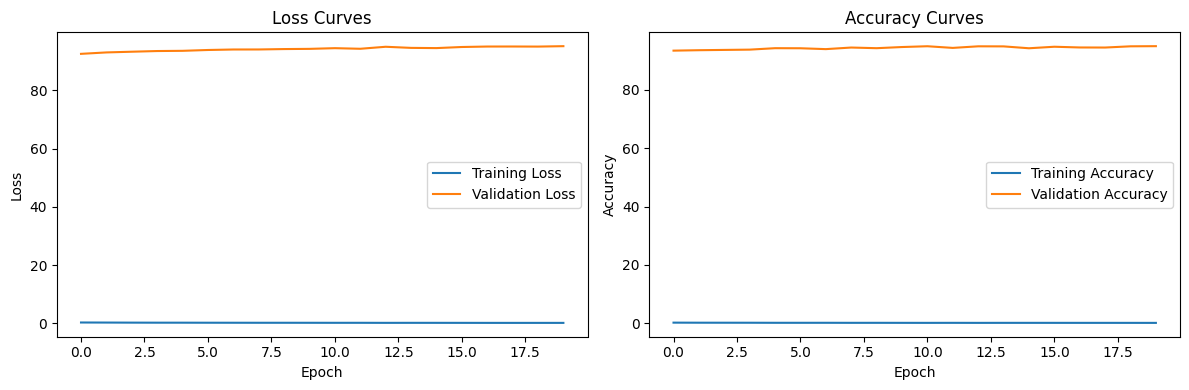

Training complete.


In [ ]:
from sklearn.metrics import classification_report  # Import classification_report
import torch

def get_all_predictions(model, dataloader):
    """Gets all predictions and true labels from a dataloader."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_preds, all_labels  # Assurez-vous que le return est bien placé en fin de fonction

# Vérifie que trained_model et DEVICE sont bien définis
if __name__ == "__main__":
    train_preds, train_labels = get_all_predictions(trained_model, train_dataloader)
    val_preds, val_labels = get_all_predictions(trained_model, val_dataloader)
    test_preds, test_labels = get_all_predictions(trained_model, test_dataloader)

    # Vérification des prédictions
    print("Train predictions:", len(train_preds))
    print("Validation predictions:", len(val_preds))
    print("Test predictions:", len(test_preds))

    # Classification reports
    print("***** Train Classification Report *****")
    print(classification_report(train_labels, train_preds, target_names=[f"class_{i}" for i in range(10)]))

    print("***** Validation Classification Report *****")
    print(classification_report(val_labels, val_preds, target_names=[f"class_{i}" for i in range(10)]))

    print("***** Test Classification Report *****")
    print(classification_report(test_labels, test_preds, target_names=[f"class_{i}" for i in range(10)]))

    # Vérifie si les variables utilisées dans plot_curves existent
    try:
        plot_curves(train_losses, val_losses, train_accs, val_accs)
    except NameError:
        print("plot_curves: Les variables train_losses, val_losses, train_accs, val_accs ne sont pas définies.")

    # Fermer le writer si défini
    if "writer" in locals():
        writer.close()

    print("Training complete.")
